# **<span style="font-family: Arial">Music Recommendation Algorithm - Data Cleaning, Pre-processing and Dimensionality Analysis  </span>**

**Author:** Ozor Moya

**Date:** 05/24/2026

**Goal:** To take messy, mixed-type, differently-scaled raw data and converts it into a clean, numeric, equally-weighted, lower-dimensional matrix that KMeans can measure distances on fairly and accurately.

---
### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

---
### 2. Load the dataset

In [3]:
df = pd.read_csv('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/music_rec/train.csv')
df.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


- Here, I used the original CSV file since no data cleaning was performed during my EDA.

---
### 3. Handle null values and duplicates

- Although in EDA I discovered that there in no null and duplicated values in this dataset, it is safer to always verify it first. There's no harm in double checking the dataset and repeating this process.

In [4]:
print(df.isnull().sum())

Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64


In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


---
### 4. Dropping columns

In [6]:
# Drop lyrics (text), artist_name, track_name, release_date (identifiers)
drop_cols = ['lyrics', 'artist_name', 'track_name', 'release_date', 'Unnamed: 0']
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)
print("After dropping identifiers & lyrics:", df.shape)
print(df.columns.tolist())

After dropping identifiers & lyrics: (28362, 19)
['genre', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'topic', 'age']


- Dropping these non-numerical columns as stated in my first notebook.

**Reasons for dropping:**
- `lyrics` - Raw text — KMeans cannot compute a distance between two strings.
- `artist_name` - An identifier, not a feature. Two songs by the same artist can be completely different in theme and mood. Including it would make the model cluster by artist name rather than song content.
- `track_name` - Same reason as artist_name — a label, not a signal.
- `release_date` - The raw year (e.g. 1975, 2003) is already captured in a better form by the `age` column, which normalizes release year to a 0–1 scale. Keeping both would double-count temporal information.
- `Unnamed: 0` - An auto-generated row index that pandas sometimes adds when reading CSVs. It carries no information, it's just a row number.

---
### 5. Encode Categorical Columns (`genre`, `topic`)

- Converting `genre` (7 categories: pop, rock, hip hop, etc.) and `topic` (8 categories: sadness, romantic, violence, etc.) from text strings into integer numbers using `LabelEncoder`.

Why LabelEncoder (not One-Hot Encoding)

- One-Hot Encoding creates a new binary column for each category (e.g. `is_pop`, `is_rock`, `is_hiphop`). With 7 genres + 8 topics = 15 extra columns, this adds significant dimensionality and can distort distance calculations. LabelEncoder assigns a single integer per category (pop=4, rock=5, hip hop=2, etc.), keeping the feature space compact.

> **Note:** LabelEncoder implies an ordinal relationship (e.g. rock > pop numerically) which isn't semantically true. However, for clustering purposes this is acceptable because PCA (applied later) will redistribute this signal across components rather than treating the integers as literal rankings.

In [8]:
le_genre = LabelEncoder()
le_topic = LabelEncoder()
df['genre_enc'] = le_genre.fit_transform(df['genre'])
df['topic_enc'] = le_topic.fit_transform(df['topic'])

print("Genre mapping:", dict(zip(le_genre.classes_, le_genre.transform(le_genre.classes_))))
print("Topic mapping:", dict(zip(le_topic.classes_, le_topic.transform(le_topic.classes_))))

df = df.drop(columns=['genre', 'topic'])
print("\nShape after encoding:", df.shape)

Genre mapping: {'blues': np.int64(0), 'country': np.int64(1), 'hip hop': np.int64(2), 'jazz': np.int64(3), 'pop': np.int64(4), 'reggae': np.int64(5), 'rock': np.int64(6)}
Topic mapping: {'feelings': np.int64(0), 'music': np.int64(1), 'night/time': np.int64(2), 'obscene': np.int64(3), 'romantic': np.int64(4), 'sadness': np.int64(5), 'violence': np.int64(6), 'world/life': np.int64(7)}

Shape after encoding: (28362, 19)


---
### 6. Removing/Cap outliers

In [9]:
num_features = [c for c in df.columns if c not in ['genre_enc', 'topic_enc']]

print("Outlier capping (99th percentile) on numeric features:")
for col in num_features:
    cap = df[col].quantile(0.99)
    n_capped = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    if n_capped > 0:
        print(f"  {col}: capped {n_capped} values above {cap:.4f}")

print("\nShape after capping:", df.shape)

Outlier capping (99th percentile) on numeric features:
  len: capped 265 values above 192.0000
  dating: capped 284 values above 0.2642
  violence: capped 284 values above 0.6736
  world/life: capped 284 values above 0.6524
  night/time: capped 284 values above 0.4994
  shake the audience: capped 284 values above 0.1983
  family/gospel: capped 284 values above 0.2099
  romantic: capped 284 values above 0.4954
  communication: capped 284 values above 0.4362
  obscene: capped 284 values above 0.7018
  music: capped 284 values above 0.5438
  movement/places: capped 284 values above 0.4000
  light/visual perceptions: capped 284 values above 0.3949
  family/spiritual: capped 284 values above 0.2506
  sadness: capped 284 values above 0.6725
  feelings: capped 284 values above 0.3794
  age: capped 216 values above 0.9429

Shape after capping: (28362, 19)


- KMeans places cluster centroids at the **mean** of all points assigned to that cluster. Means are highly sensitive to extreme values, one song with `len = 199` (the maximum) can pull a centroid significantly away from where the true center of the cluster should be.

---
### 7. Check for Highly Correlated Features

In [10]:
corr = df[num_features].corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(col, row, round(upper.loc[row, col], 3))
             for col in upper.columns
             for row in upper.index
             if abs(upper.loc[row, col]) > 0.85]

if high_corr:
    print("Highly correlated pairs (r > 0.85) — will drop one from each pair:")
    for pair in high_corr:
        print(f"  {pair}")
    to_drop = list(set([p[1] for p in high_corr]))
    df = df.drop(columns=to_drop)
    print(f"  Dropped: {to_drop}")
else:
    print("No feature pairs exceed r = 0.85. No columns dropped for multicollinearity.")
    print("(Aligns with EDA — all features carry independent signal.)")

print("\nFinal feature list:", df.columns.tolist())

No feature pairs exceed r = 0.85. No columns dropped for multicollinearity.
(Aligns with EDA — all features carry independent signal.)

Final feature list: ['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age', 'genre_enc', 'topic_enc']


If two features are highly correlated (r > 0.85), they are near-duplicates of each other in terms of the information they carry. Keeping both:
- **Double-counts** that signal in distance calculations, inflating its importance
- **Adds noise** without adding new information
- **Increases dimensionality** unnecessarily


---
### 8. Scale Features with StandardScaler

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)

print("Scaled data shape:", X_scaled_df.shape)
print("\nMean after scaling (should be ~0):")
print(X_scaled_df.mean().round(6))
print("\nStd after scaling (should be ~1):")
print(X_scaled_df.std().round(4))

Scaled data shape: (28362, 19)

Mean after scaling (should be ~0):
len                        -0.0
dating                      0.0
violence                    0.0
world/life                  0.0
night/time                 -0.0
shake the audience         -0.0
family/gospel              -0.0
romantic                    0.0
communication               0.0
obscene                     0.0
music                       0.0
movement/places            -0.0
light/visual perceptions   -0.0
family/spiritual            0.0
sadness                    -0.0
feelings                   -0.0
age                        -0.0
genre_enc                  -0.0
topic_enc                  -0.0
dtype: float64

Std after scaling (should be ~1):
len                         1.0
dating                      1.0
violence                    1.0
world/life                  1.0
night/time                  1.0
shake the audience          1.0
family/gospel               1.0
romantic                    1.0
communication      

- When KMeans computes the distance between two songs, it adds up the squared differences across all features. A difference of 50 on `len` contributes 2,500 to that sum. A difference of 0.3 on `romantic` contributes only 0.09. Without scaling, **`len` alone would dominate every cluster assignment** regardless of what the theme scores say.

- After StandardScaler, every feature contributes equally. A 1-unit difference means the same thing across all features, it represents 1 standard deviation.

---
### 9. PCA (Principal Component Analysis)

- Here in this step, I will reduce the 19 scaled features down to a smaller number of **principal components** that together explain at least 85–90% of the total variance in the data.

#### 9.1 Fit PCA on All Components & Plot Explained Variance

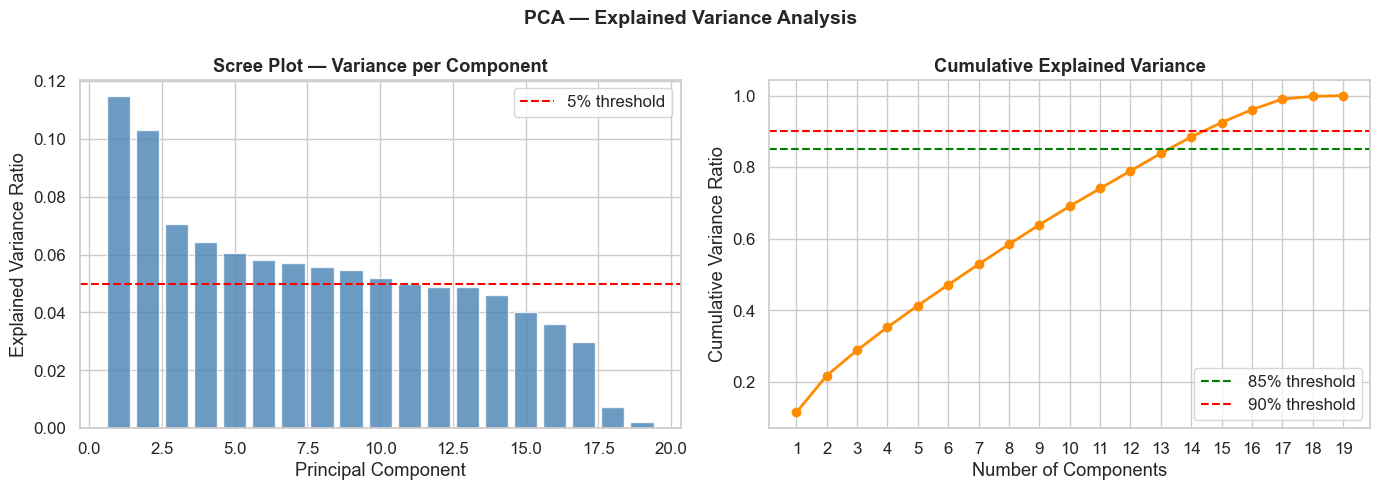

80% variance explained by 13 components
85% variance explained by 14 components
90% variance explained by 15 components
95% variance explained by 16 components


In [12]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled_df)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.8)
axes[0].set_title('Scree Plot — Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].axhline(y=0.05, color='red', linestyle='--', label='5% threshold')
axes[0].legend()

# Cumulative variance
axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=0.85, color='green', linestyle='--', label='85% threshold')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative)+1))

plt.suptitle('PCA — Explained Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Docs/fig15_PCA.png', dpi=150, bbox_inches='tight')
plt.show()

for threshold in [0.80, 0.85, 0.90, 0.95]:
    n = np.argmax(cumulative >= threshold) + 1
    print(f"{int(threshold*100)}% variance explained by {n} components")

**Scree Plot (left):** Each bar shows how much variance a single component explains on its own. You're looking for the point where bars become very small, those components are mostly noise. In our data the first few components carry substantial variance, then it tapers off.

**Cumulative Variance Plot (right):** This is the decision chart. The curve starts low and rises as you add more components. Where it crosses the green 85% line is where you stop. Adding more components beyond that point gives diminishing returns, tiny variance gains for added dimensionality and noise.

---
#### 9.2 Apply PCA with Chosen Number of Components

In [13]:
N_COMPONENTS = int(np.argmax(cumulative >= 0.85) + 1)
print(f"Chosen number of PCA components: {N_COMPONENTS} (covers >= 85% variance)")

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(N_COMPONENTS)], index=df.index)

print(f"PCA output shape: {X_pca_df.shape}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.4f}")
X_pca_df.head(3)

Chosen number of PCA components: 14 (covers >= 85% variance)
PCA output shape: (28362, 14)
Total variance captured: 0.8845


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,0.496553,1.082219,-1.397833,-0.772258,0.778972,0.572968,1.497797,-0.197341,-0.133055,0.749815,0.698580,0.650449,-0.573701,1.067722
1,2.274500,0.261477,1.869530,1.146213,-0.942924,-1.226515,0.061855,-0.577677,-0.151830,-0.279899,0.619603,-0.275371,0.519277,0.659182
2,-0.926250,3.513248,-0.077179,-0.978525,-1.115643,-0.477947,2.653549,0.242785,0.947926,1.951869,-0.626659,0.173853,-0.421447,1.068882


---
#### 9.3 Component Loadings Heatmap

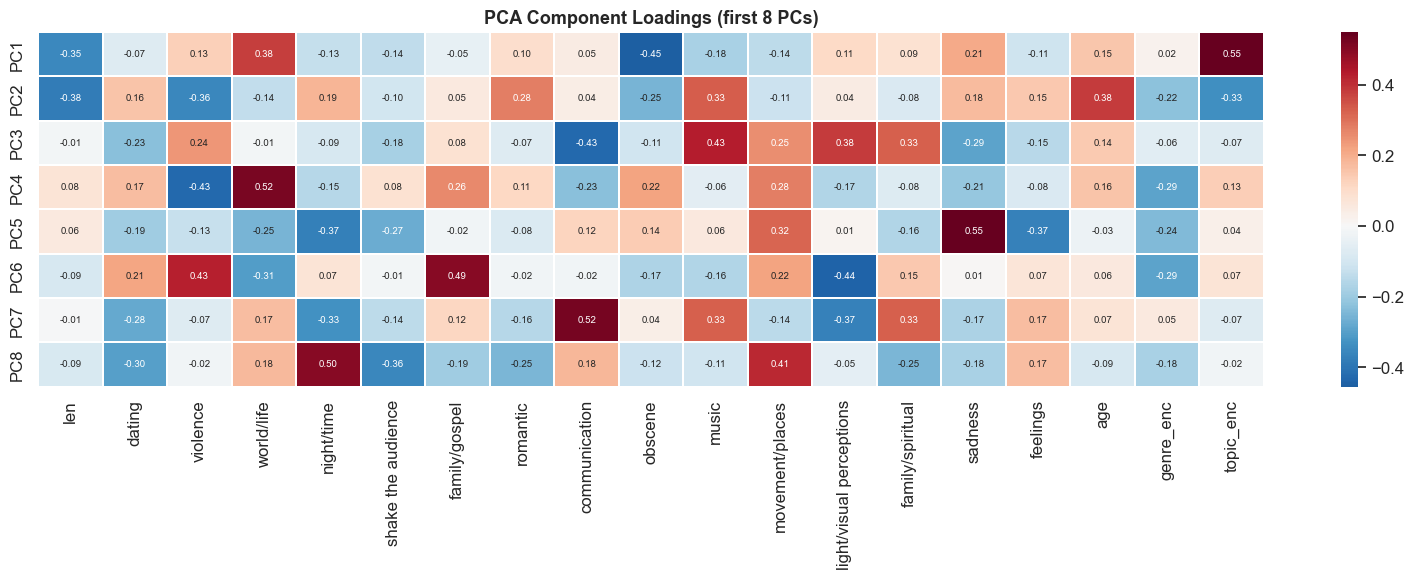

In [14]:
loadings = pd.DataFrame(pca.components_[:8],
                        columns=df.columns,
                        index=[f'PC{i+1}' for i in range(min(8, N_COMPONENTS))])

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('PCA Component Loadings (first 8 PCs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Docs/fig15_PCA_heatmap.png', dpi=150, bbox_inches='tight')

- Here, the heatmap shows how much each original feature contributes to each principal component. For example, PC1 is mainly driven by topic_enc (strong positive) and obscene and len (strong negative), meaning it separates explicit, wordy songs from topic-labeled ones, this is the most important axis since PC1 captures the most variance. Each subsequent PC captures a different, independent dimension of variation: PC2 separates violent songs from romantic ones, PC3 captures musical and spiritual performance, and so on down to PC8 which isolates nocturnal/atmospheric content.

---
### 10. Save cleaned data

In [16]:
X_pca_df.to_csv('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/train_cleaned.csv', index=False)
print("Saved train_cleaned.csv with shape:", X_pca_df.shape)
print("\nColumn names:", X_pca_df.columns.tolist())

import pickle
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/pca.pkl', 'wb') as f:
    pickle.dump(pca, f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/feature_cols.pkl', 'wb') as f:
    pickle.dump(df.columns.tolist(), f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/le_genre.pkl', 'wb') as f:
    pickle.dump(le_genre, f)
with open('/Users/sa02/class-projects/EOP-Project/music-recommendation-algorithm/Data/le_topic.pkl', 'wb') as f:
    pickle.dump(le_topic, f)
print("\nScaler, PCA, and encoders saved for test set use.")

Saved train_cleaned.csv with shape: (28362, 14)

Column names: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14']

Scaler, PCA, and encoders saved for test set use.


---
### Summary

- In this notebook, I transformed the raw training dataset into a clean, model-ready matrix ready for KMeans clustering. The process started by re-verifying that there were no null values or duplicate rows, confirming what was already found in EDA, before dropping five non-numeric or identifier columns: `lyrics`, `artist_name`, `track_name`, `release_date`, and `Unnamed: 0`. The two remaining categorical columns, `genre` and `topic`, were retained and label-encoded into integers so their discriminating signal could be preserved in the feature matrix.

- With all columns now numeric, outliers were capped at the 99th percentile to prevent extreme values from distorting cluster centroids, and a correlation check confirmed that no feature pair exceeded r = 0.85, meaning all 19 features carry independent signal and none needed to be dropped for redundancy. StandardScaler was then applied to rescale every feature to mean = 0 and standard deviation = 1, ensuring that large-scale features like `len` (0–200) do not dominate distance calculations over small-scale features like `romantic` (0–1).

- Finally, PCA reduced the 19 scaled features down to 14 principal components that together capture 88.5% of the total variance in the data, enough to preserve the meaningful structure while removing noise and reducing dimensionality for cleaner clustering. The resulting `train_cleaned.csv` is a 28,362 × 14 matrix passed directly into the modeling notebook. The fitted scaler, PCA, and encoders were also saved as `.pkl` files so the test dataset can be transformed using the exact same parameters, ensuring both datasets live in the same feature space when cluster predictions are made.